In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

# step 1 load data

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# step 2 data preprocessing Normalize data(make value between 0 and 1)
X_train = X_train / 255.0
X_test = X_test / 255.0


# step 3 create a neural network

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)), # convert image 28 x 28 = 784 number
    keras.layers.Dense(128, activation='relu'), # hidden layer 1
    keras.layers.Dense(64, activation='relu'), # hidden layer 2
    keras.layers.Dense(10, activation='softmax') # output layer
])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [2]:
# step 4 complie the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [3]:
# step 5 train the model
model.fit(X_train, y_train, epochs=10,validation_data=(X_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9289 - loss: 0.2419 - val_accuracy: 0.9590 - val_loss: 0.1349
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9678 - loss: 0.1044 - val_accuracy: 0.9730 - val_loss: 0.0880
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9773 - loss: 0.0729 - val_accuracy: 0.9673 - val_loss: 0.1058
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9830 - loss: 0.0543 - val_accuracy: 0.9761 - val_loss: 0.0828
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9859 - loss: 0.0427 - val_accuracy: 0.9724 - val_loss: 0.0887
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9883 - loss: 0.0350 - val_accuracy: 0.9772 - val_loss: 0.0826
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9899 - loss: 0.0312 - val_accuracy: 0.9729 - val_loss: 0.0893
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9919 - loss: 0.0250

In [4]:
# step 6 check accuracy on test data
test_loss , test_acc = model.evaluate(X_test, y_test)
print('Test accuracy:', test_acc)
print(f'Test accuracy = {test_acc*100:.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9776 - loss: 0.0915
Test accuracy: 0.9775999784469604
Test accuracy = 97.76%


In [5]:
# step 7 predictions on first 5 test image
predictions = model.predict(X_test[:5])
print(np.argmax(predictions, axis=1))
print(y_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
[7 2 1 0 4]
[7 2 1 0 4]


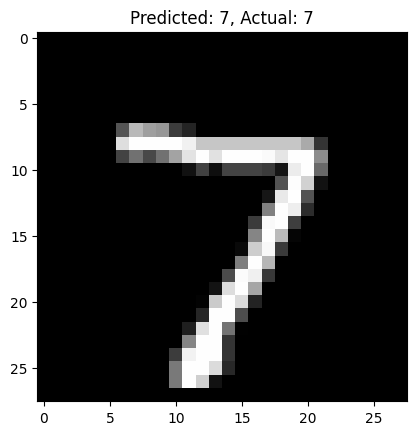

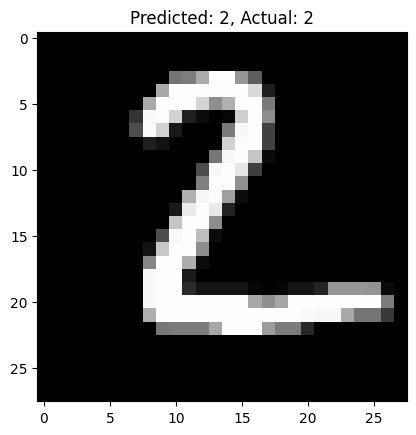

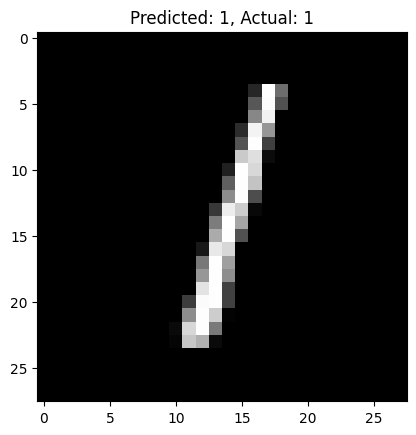

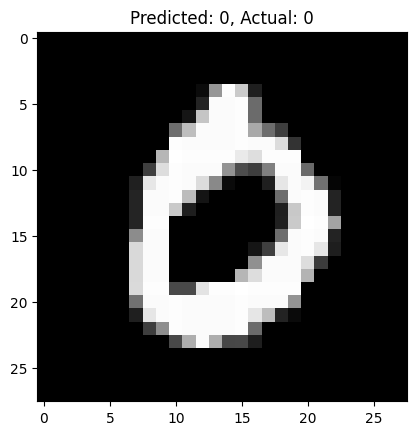

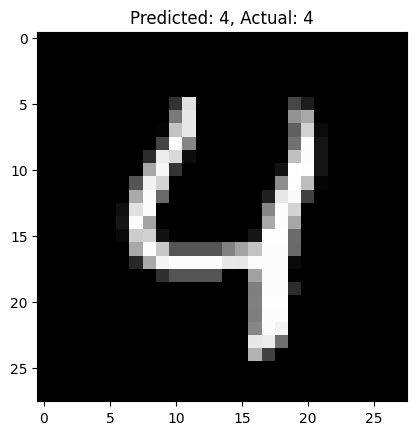

In [6]:
for i in range(5):
  plt.imshow(X_test[i],cmap='gray')
  plt.title(f'Predicted: {np.argmax(predictions[i])}, Actual: {y_test[i]}')
  plt.show()